# Speed and Gyro information

In [1]:
import os
import numpy as np
import pynwb

import spyglass as nd
import datajoint as dj
import multiprocessing

# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)
warnings.simplefilter('ignore', category=UserWarning)

import matplotlib.pyplot as plt

In [2]:
from position_tools import get_speed,get_distance
from scipy.ndimage.filters import gaussian_filter1d

In [23]:
nwb_filename='eliot20221020.nwb'
nwb_copy_filename='eliot20221020_.nwb'

In [22]:
io = pynwb.NWBHDF5IO('/stelmo/nwb/raw/'+nwb_filename,'r')
nwbf = io.read()

In [14]:
spatial_series=nwbf.processing['behavior']['position']['series_1']

### LED Position and speed

In [15]:
# position
position=nwbf.processing['behavior']['position']['series_1'].data
time=nwbf.processing['behavior']['position']['series_1'].timestamps

In [16]:
# obtain speed
CM_TO_METERS = 100
max_LED_separation = 9
speed_smoothing_std_dev=0.1 # in seconds

# remove NaN times
is_nan_time = np.isnan(time)
position = position[~is_nan_time,:]
time = time[~is_nan_time]

dt = np.median(np.diff(time))
sampling_rate = 1 / dt
meters_to_pixels = spatial_series.conversion

# Define LEDs
front_LED = position[:, [0, 1]].astype(float)
back_LED = position[:, [2, 3]].astype(float)

# Convert to cm
back_LED *= meters_to_pixels * CM_TO_METERS
front_LED *= meters_to_pixels * CM_TO_METERS

# Set points to NaN where the front and back LEDs are too separated
dist_between_LEDs = get_distance(back_LED, front_LED)
is_too_separated = dist_between_LEDs >= max_LED_separation

back_LED[is_too_separated] = np.nan
front_LED[is_too_separated] = np.nan

# Calculate speed
front_LED_speed = get_speed(
    front_LED,
    time,sigma=speed_smoothing_std_dev,
    sampling_frequency=sampling_rate)
back_LED_speed = get_speed(
    back_LED,
    time,
    sigma=speed_smoothing_std_dev,
    sampling_frequency=sampling_rate)

### Headstage gyro

In [17]:
# gyro
gyrodata=nwbf.processing['analog']['analog'].time_series['analog'].data
gyrotimestamps=nwbf.processing['analog']['analog'].time_series['analog'].timestamps

In [18]:
gyrotimestamps[1]

1666280452.0367427

### Find run epoch time window

In [20]:
from spyglass.common import IntervalList

[2024-03-22 13:42:10,735][INFO]: Connecting shijiegu@lmf-db.cin.ucsf.edu:3306
[2024-03-22 13:42:10,800][INFO]: Connected shijiegu@lmf-db.cin.ucsf.edu:3306


In [41]:
valid_t=(IntervalList & {'nwb_file_name': nwb_copy_filename,'interval_list_name':'02_Seq2Session1'}).fetch1('valid_times')
valid_t
print(valid_t[0][0])
print(valid_t[0][1])

1666282567.6079278
1666284840.8475842


In [42]:
start_time=valid_t[0][0]+600
end_time=valid_t[0][0]+630

gyro_ind=np.argwhere(np.logical_and(gyrotimestamps>=start_time,gyrotimestamps<=end_time)).ravel()
pos_ind=np.argwhere(np.logical_and(time>=start_time,time<=end_time))

In [48]:
gyro_plot=np.sqrt((gyrodata[gyro_ind,0])**2+(gyrodata[gyro_ind,1])**2)
gyro_plot_filtered=gaussian_filter1d(gyro_plot,30000*0.1,mode='constant')

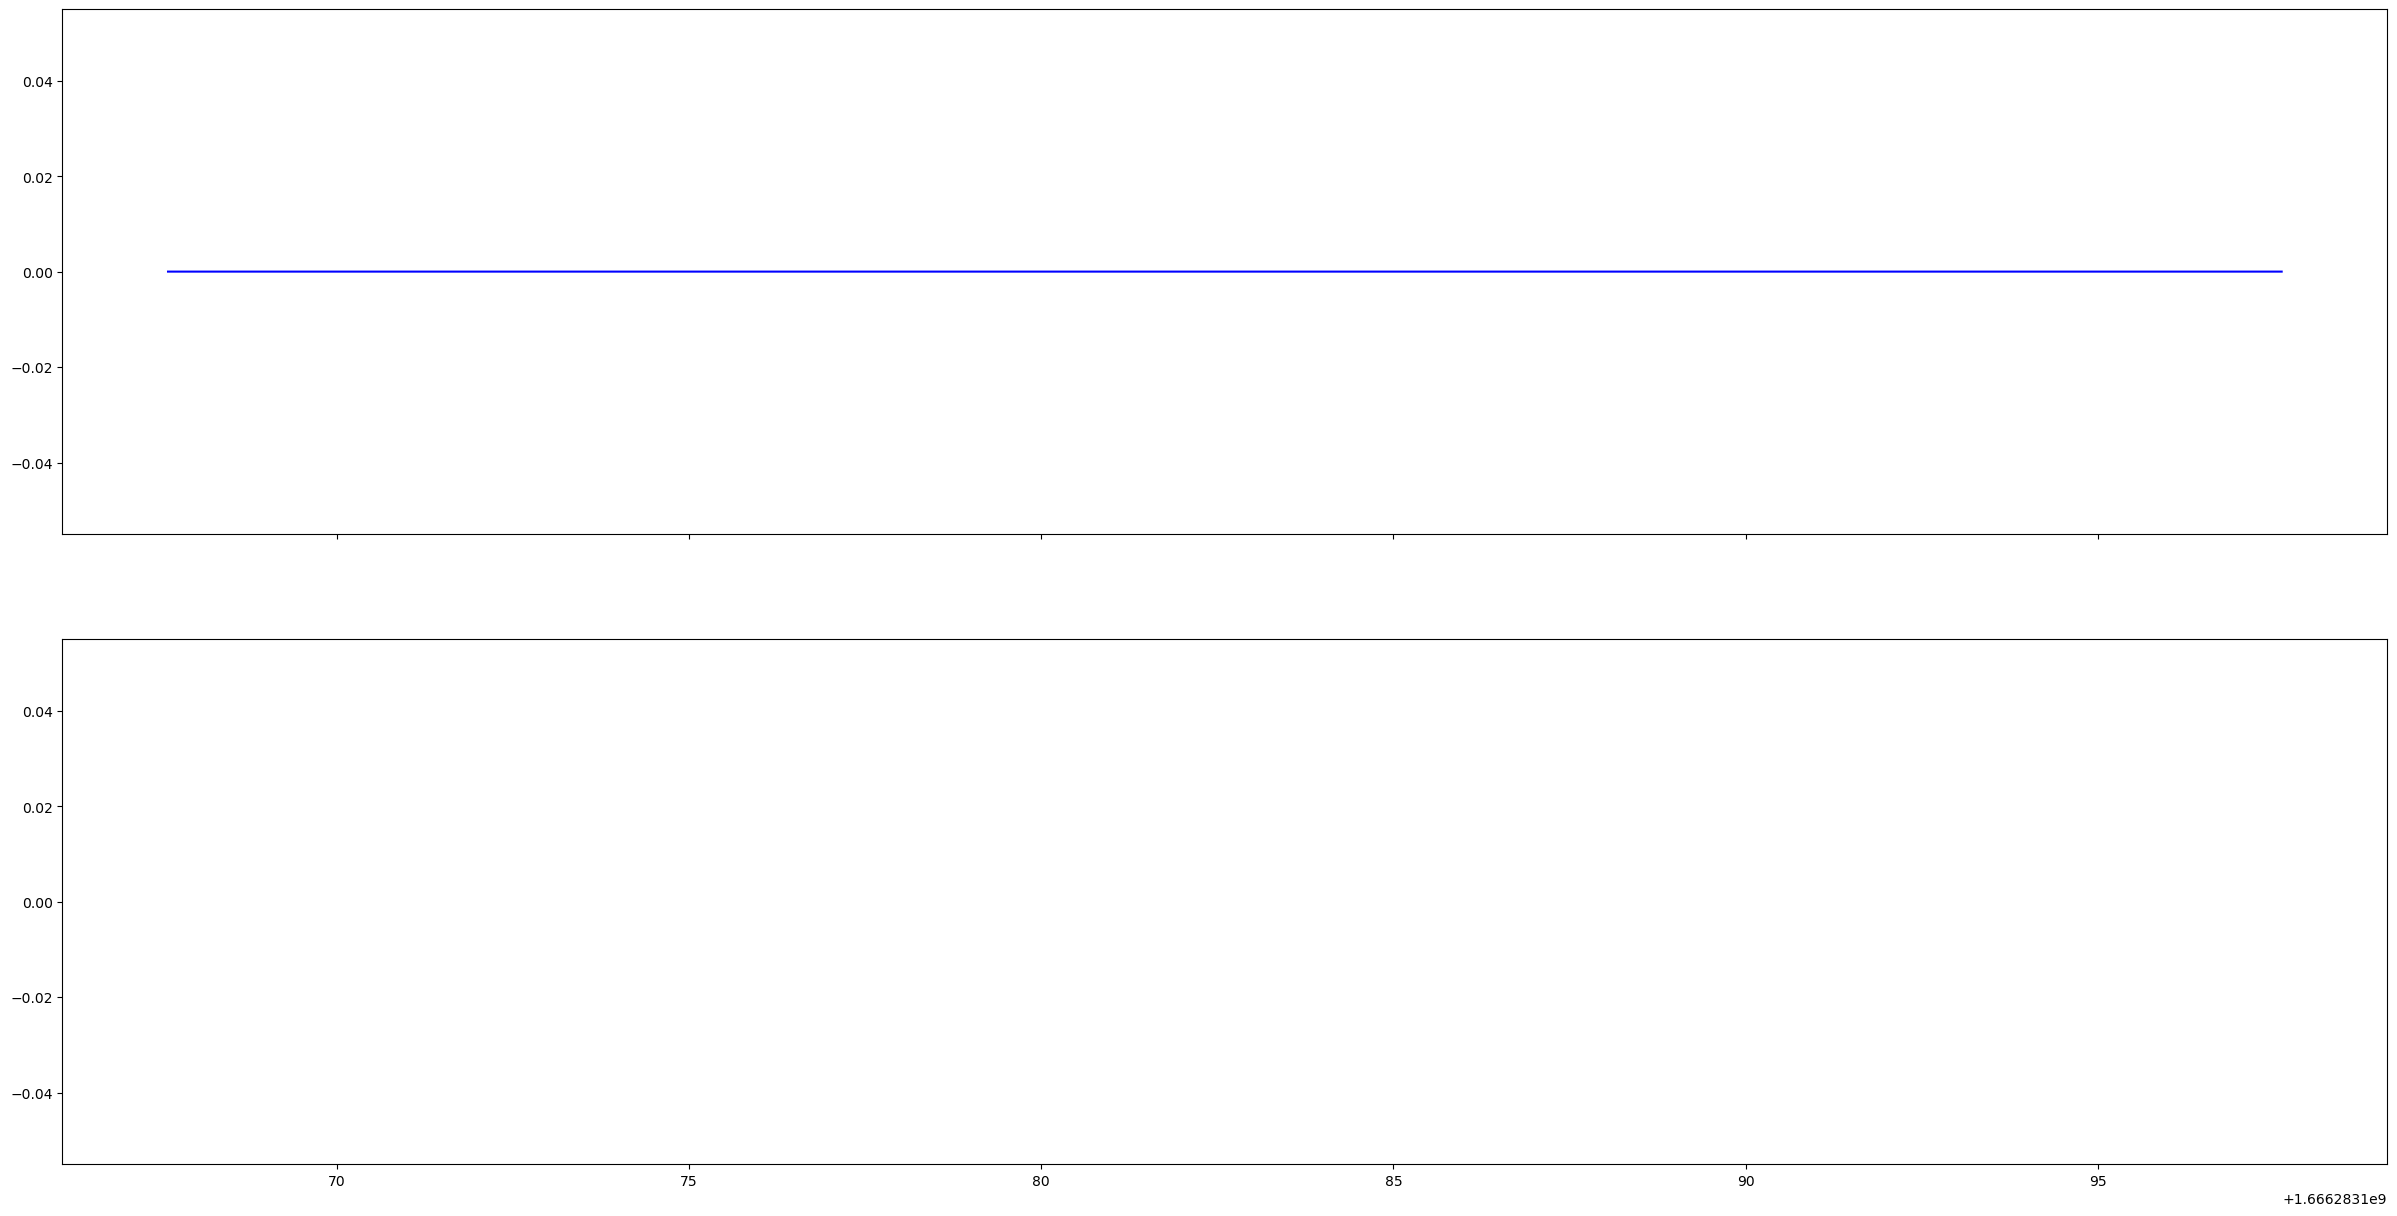

In [49]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(30, 15))
ax[0].plot(gyrotimestamps[gyro_ind],gyro_plot,'b-')
ax[1].plot(time[pos_ind],back_LED_speed[pos_ind],'g-')

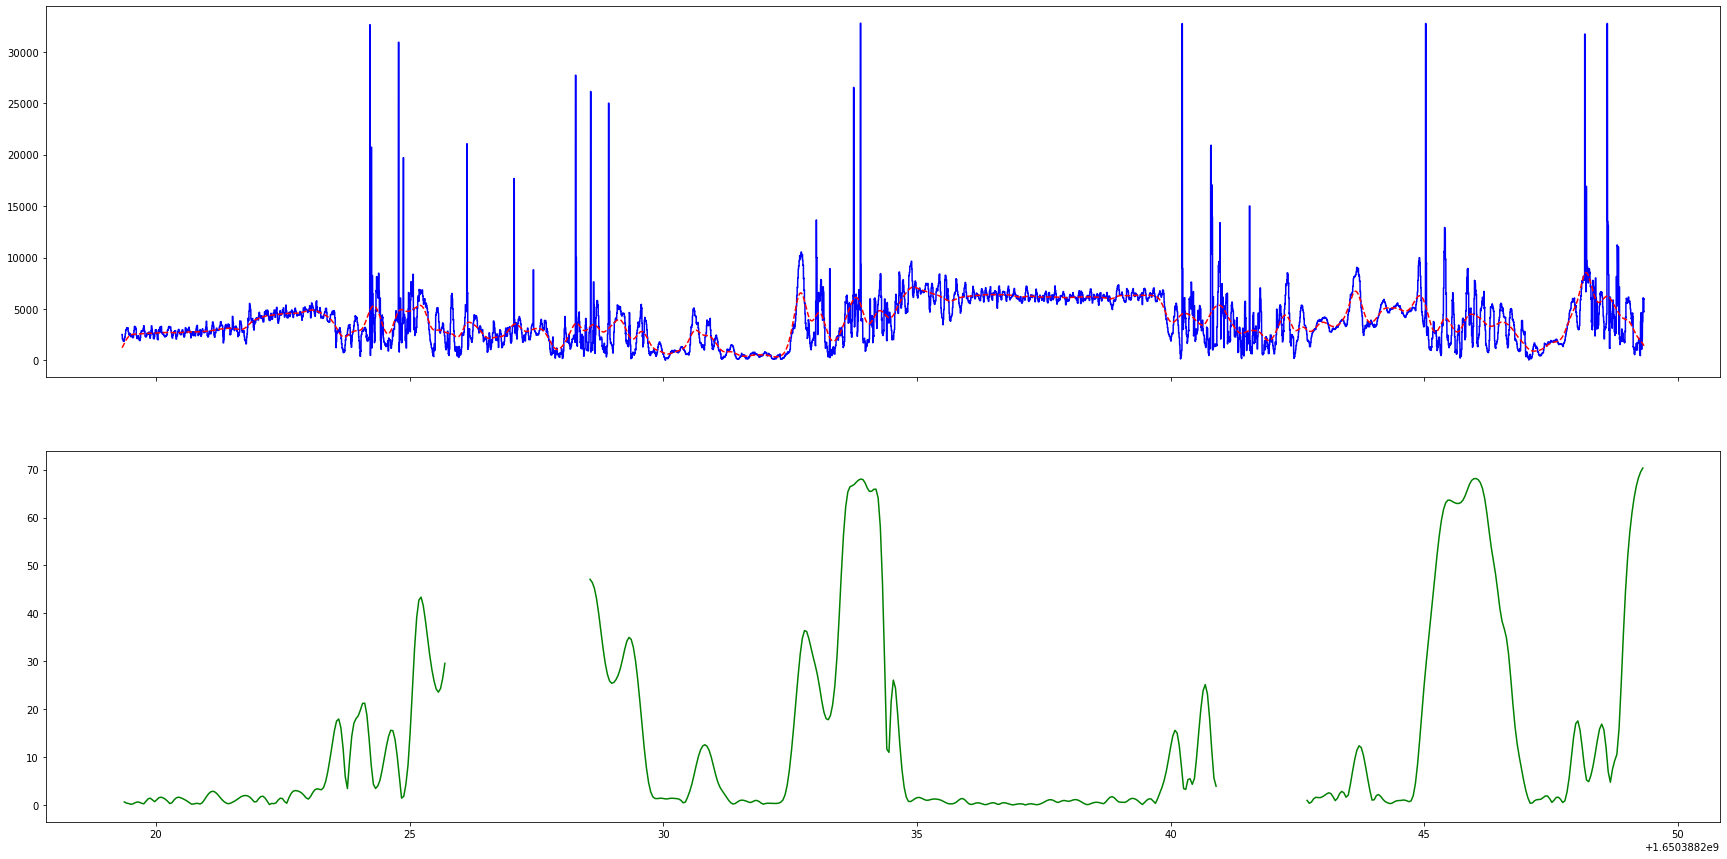

In [89]:
start_time=valid_t[0][0]+800 # in seconds
end_time=valid_t[0][0]+830

gyro_ind=np.argwhere(np.logical_and(gyrotimestamps>=start_time,gyro_timestamps<=end_time))
pos_ind=np.argwhere(np.logical_and(time>=start_time,time<=end_time))

gyro_plot=np.sqrt((gyrodata[gyro_ind,0])**2+(gyrodata[gyro_ind,1])**2)
gyro_plot_filtered=gaussian_filter1d(gyro_plot,30000*0.1,mode='constant')

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(30, 15))
ax[0].plot(gyrotimestamps[gyro_ind],gyro_plot,'b-')
ax[0].plot(gyrotimestamps[gyro_ind],gyro_plot_filtered,'r--')
ax[1].plot(time[pos_ind],back_LED_speed[pos_ind],'g-')

In [ ]:
from spyglass.common.common_position import PositionVideo

PositionVideo().make({'nwb_file_name': 'molly20220419_.nwb',
                      'interval_list_name': 'pos 1 valid times',
                      'position_info_param_name': 'default'
                     })

### Since from the examples that gyro and LED speed matches well, replay decoding uses LED speed